# Stroke Risk Prediction — Model Development

**Ansh Patel** — [github.com/anshcpatel11](https://github.com/anshcpatel11)

This notebook covers exploratory data analysis, feature engineering, model development,
and evaluation for the stroke risk prediction pipeline. The final trained model is
deployed as an interactive Streamlit application via `app.py`.

**Dataset:** UCI Stroke Prediction (5,110 patient records, 4.9% positive rate)
**Techniques:** Clinical feature engineering, random oversampling, stacking ensemble, threshold optimization, permutation importance

## 1. Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils import resample

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
RANDOM_STATE = 42
PLOTS_DIR = Path('../plots')
PLOTS_DIR.mkdir(exist_ok=True)
print('Setup complete.')

Setup complete.


## 2. Data Loading & Initial Inspection

In [2]:
df = pd.read_csv('../data/healthcare-dataset-stroke-data.csv')
# Remove the single 'Other' gender row
df = df[df['gender'] != 'Other'].reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}')
print(f'\nStroke rate: {df["stroke"].mean():.1%}')
df.head()

Shape: (5109, 12)
Missing values:
bmi    201
dtype: int64

Stroke rate: 4.9%


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 3. Exploratory Data Analysis

With only 4.9% positive rate, understanding the distribution of cases across clinical
features is critical before modeling.

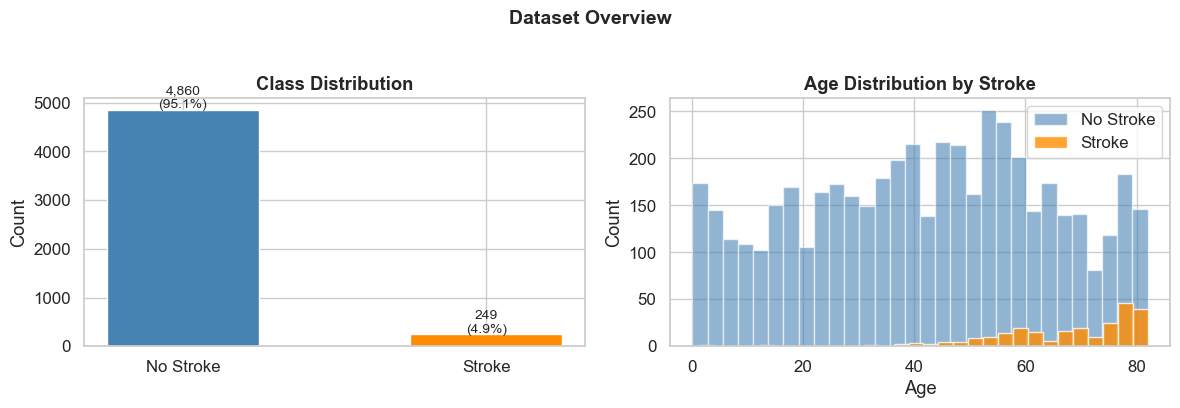

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class imbalance
counts = df['stroke'].value_counts()
axes[0].bar(['No Stroke', 'Stroke'], counts.values,
            color=['steelblue', 'darkorange'], edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=10)

# Age distribution by stroke
df[df['stroke']==0]['age'].hist(bins=30, ax=axes[1], alpha=0.6, color='steelblue', label='No Stroke')
df[df['stroke']==1]['age'].hist(bins=30, ax=axes[1], alpha=0.8, color='darkorange', label='Stroke')
axes[1].set_title('Age Distribution by Stroke', fontweight='bold')
axes[1].set_xlabel('Age'); axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Dataset Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(PLOTS_DIR / 'eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

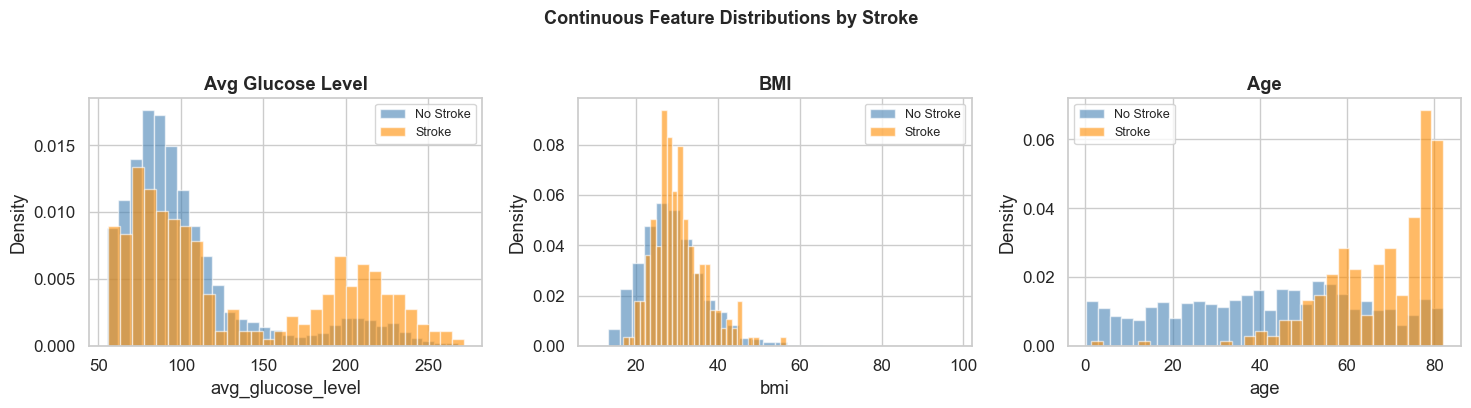

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(axes,
    ['avg_glucose_level', 'bmi', 'age'],
    ['Avg Glucose Level', 'BMI', 'Age']):
    for label, color in [(0, 'steelblue'), (1, 'darkorange')]:
        subset = df[df['stroke'] == label][col].dropna()
        ax.hist(subset, bins=30, alpha=0.6, color=color,
                label='No Stroke' if label==0 else 'Stroke', density=True)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Continuous Feature Distributions by Stroke', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(PLOTS_DIR / 'eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

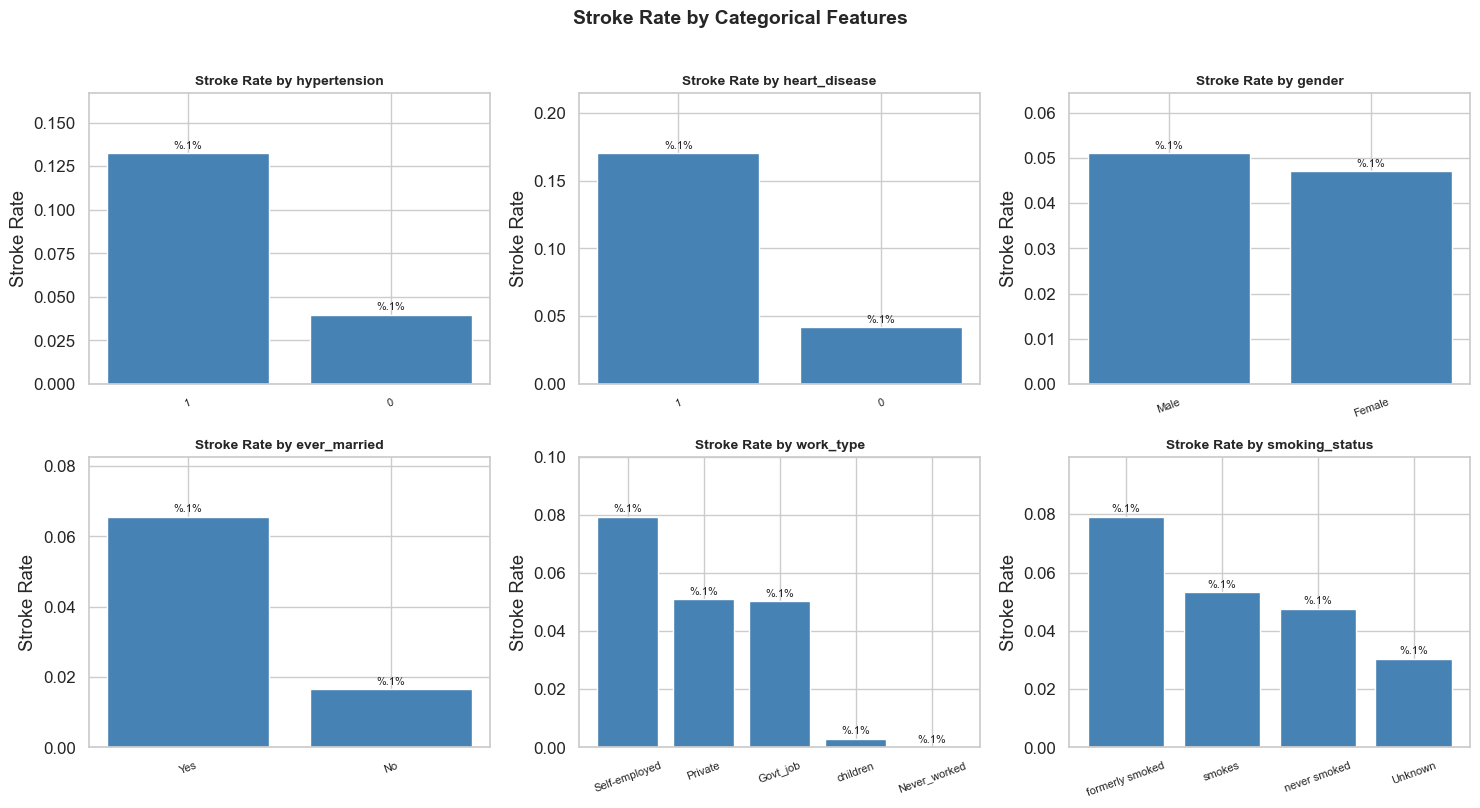

In [5]:
# Stroke rates by categorical features
cat_cols = ['hypertension', 'heart_disease', 'gender', 'ever_married',
            'work_type', 'smoking_status']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flat, cat_cols):
    stroke_rate = df.groupby(col)['stroke'].mean().sort_values(ascending=False)
    bars = ax.bar(stroke_rate.index.astype(str), stroke_rate.values,
                  color='steelblue', edgecolor='white')
    ax.bar_label(bars, fmt='%.1%', padding=2, fontsize=8)
    ax.set_title(f'Stroke Rate by {col}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Stroke Rate')
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.2)

plt.suptitle('Stroke Rate by Categorical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(PLOTS_DIR / 'eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Engineering

Raw features are augmented with clinically-motivated derived features before modeling.
These are based on established medical risk thresholds rather than data-driven binning.

In [6]:
def engineer_features(df):
    df = df.copy()
    # Clinical glucose tiers (ADA definitions)
    df['glucose_risk'] = pd.cut(
        df['avg_glucose_level'], bins=[0, 100, 125, 999],
        labels=['Normal', 'Prediabetic', 'Diabetic']
    ).astype(str)
    # BMI categories (WHO)
    df['bmi_category'] = pd.cut(
        df['bmi'], bins=[0, 18.5, 25, 30, 999],
        labels=['Underweight', 'Normal', 'Overweight', 'Obese']
    ).astype(str)
    # Age risk tiers
    df['age_group'] = pd.cut(
        df['age'], bins=[0, 40, 55, 65, 999],
        labels=['Under40', '40to55', '55to65', 'Over65']
    ).astype(str)
    # Cardiovascular comorbidity score
    df['comorbidity_score'] = df['hypertension'].astype(int) + df['heart_disease'].astype(int)
    # Interaction features
    df['age_x_hypertension']  = df['age'] * df['hypertension']
    df['age_x_heart_disease'] = df['age'] * df['heart_disease']
    return df

df = engineer_features(df)
print('Engineered features added:')
print([c for c in df.columns if c not in [
    'id','gender','age','hypertension','heart_disease','ever_married',
    'work_type','Residence_type','avg_glucose_level','bmi','smoking_status','stroke'
]])

Engineered features added:
['glucose_risk', 'bmi_category', 'age_group', 'comorbidity_score', 'age_x_hypertension', 'age_x_heart_disease']


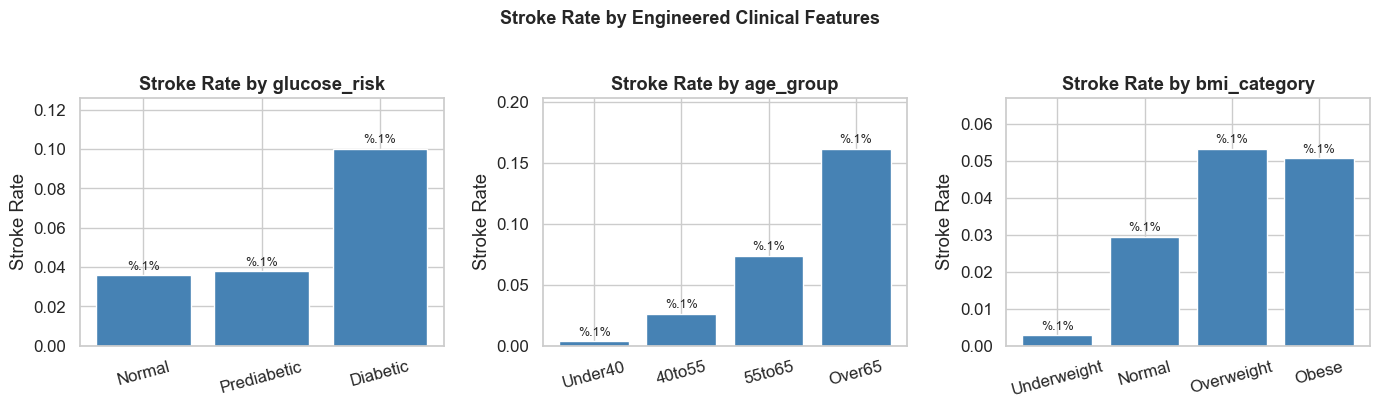

In [7]:
# Visualize glucose risk tier vs stroke rate
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ['glucose_risk', 'age_group', 'bmi_category']):
    order_map = {
        'glucose_risk':  ['Normal', 'Prediabetic', 'Diabetic'],
        'age_group':     ['Under40', '40to55', '55to65', 'Over65'],
        'bmi_category':  ['Underweight', 'Normal', 'Overweight', 'Obese'],
    }
    order = order_map[col]
    rates = df.groupby(col)['stroke'].mean().reindex(order)
    bars = ax.bar(rates.index, rates.values, color='steelblue', edgecolor='white')
    ax.bar_label(bars, fmt='%.1%', padding=2, fontsize=9)
    ax.set_title(f'Stroke Rate by {col}', fontweight='bold')
    ax.set_ylabel('Stroke Rate')
    ax.tick_params(axis='x', rotation=15)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.2)

plt.suptitle('Stroke Rate by Engineered Clinical Features', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(PLOTS_DIR / 'engineered_feature_rates.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Preprocessing & Train/Test Split

In [8]:
X = df.drop(columns=['id', 'stroke'])
y = df['stroke']

numeric_features     = ['age', 'avg_glucose_level', 'bmi',
                         'comorbidity_score', 'age_x_hypertension', 'age_x_heart_disease']
binary_features      = ['hypertension', 'heart_disease']
categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type',
                         'smoking_status', 'glucose_risk', 'bmi_category', 'age_group']

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
bin_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent'))])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, numeric_features),
    ('bin', bin_pipe, binary_features),
    ('cat', cat_pipe, categorical_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f'Train: {X_train_proc.shape} | Test: {X_test_proc.shape}')
print(f'Train positive rate: {y_train.mean():.1%} | Test: {y_test.mean():.1%}')

Train: (4087, 35) | Test: (1022, 35)
Train positive rate: 4.9% | Test: 4.9%


## 6. Class Imbalance — Random Oversampling

With only 4.9% positive rate (worse than the 11% in hospital readmissions),
oversampling is essential. We use a 4:1 majority-to-minority ratio on the training set only.

In [9]:
y_train_arr = np.array(y_train)
X_maj = X_train_proc[y_train_arr == 0]
X_min = X_train_proc[y_train_arr == 1]

target_min = len(X_maj) // 4
X_min_over = resample(X_min, n_samples=target_min, replace=True, random_state=RANDOM_STATE)
y_min_over = np.ones(target_min, dtype=int)

X_train_bal = np.vstack([X_maj, X_min_over])
y_train_bal = np.concatenate([np.zeros(len(X_maj), dtype=int), y_min_over])
idx = np.random.RandomState(RANDOM_STATE).permutation(len(X_train_bal))
X_train_bal, y_train_bal = X_train_bal[idx], y_train_bal[idx]

print(f'Before: majority={len(X_maj):,} | minority={len(X_min):,}')
print(f'After:  majority={len(X_maj):,} | minority={target_min:,}')
print(f'New positive rate: {y_train_bal.mean():.1%}')

Before: majority=3,888 | minority=199
After:  majority=3,888 | minority=972
New positive rate: 20.0%


## 7. Baseline Model Comparison

In [10]:
def evaluate(name, y_true, y_pred, y_proba=None):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_proba), 4) if y_proba is not None else None,
    }

base_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=5,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'HistGradient Boosting': HistGradientBoostingClassifier(
        max_iter=200, max_depth=6, learning_rate=0.05,
        class_weight='balanced', random_state=RANDOM_STATE),
}

results, fitted = [], {}
for name, model in base_models.items():
    print(f'Training {name}...')
    model.fit(X_train_bal, y_train_bal)
    pred  = model.predict(X_test_proc)
    proba = model.predict_proba(X_test_proc)[:, 1]
    results.append(evaluate(name, y_test, pred, proba))
    fitted[name] = (model, pred, proba)

pd.DataFrame(results).set_index('Model').sort_values('F1', ascending=False)

Training Logistic Regression...
Training Random Forest...
Training HistGradient Boosting...


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Random Forest,0.8102,0.1786,0.80,0.2920,0.8343
HistGradient Boosting,0.8836,0.1947,0.44,0.2699,0.8186
Logistic Regression,0.7182,0.1281,0.82,0.2216,0.8275


## 8. Stacking Ensemble

A stacking classifier combines the three base models using a Logistic Regression meta-learner.
The meta-learner learns how to best weight each base model's predictions using 5-fold cross-validation
on the training set, which helps prevent overfitting to any single model's biases.

In [11]:
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

stacking = StackingClassifier(
    estimators=[
        ('lr',  LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)),
        ('rf',  RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=5,
                                        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)),
        ('hgb', HistGradientBoostingClassifier(max_iter=200, max_depth=6, learning_rate=0.05,
                                               class_weight='balanced', random_state=RANDOM_STATE)),
    ],
    final_estimator=LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    cv=cv_inner,
    passthrough=False,
    n_jobs=-1
)

print('Training stacking ensemble...')
stacking.fit(X_train_bal, y_train_bal)
stack_pred  = stacking.predict(X_test_proc)
stack_proba = stacking.predict_proba(X_test_proc)[:, 1]
stack_result = evaluate('Stacking Ensemble', y_test, stack_pred, stack_proba)
print('Done.')
pd.DataFrame([stack_result]).set_index('Model')

Training stacking ensemble...
Done.


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Stacking Ensemble,0.8982,0.1786,0.3,0.2239,0.7864


## 9. ROC & Precision-Recall Curves

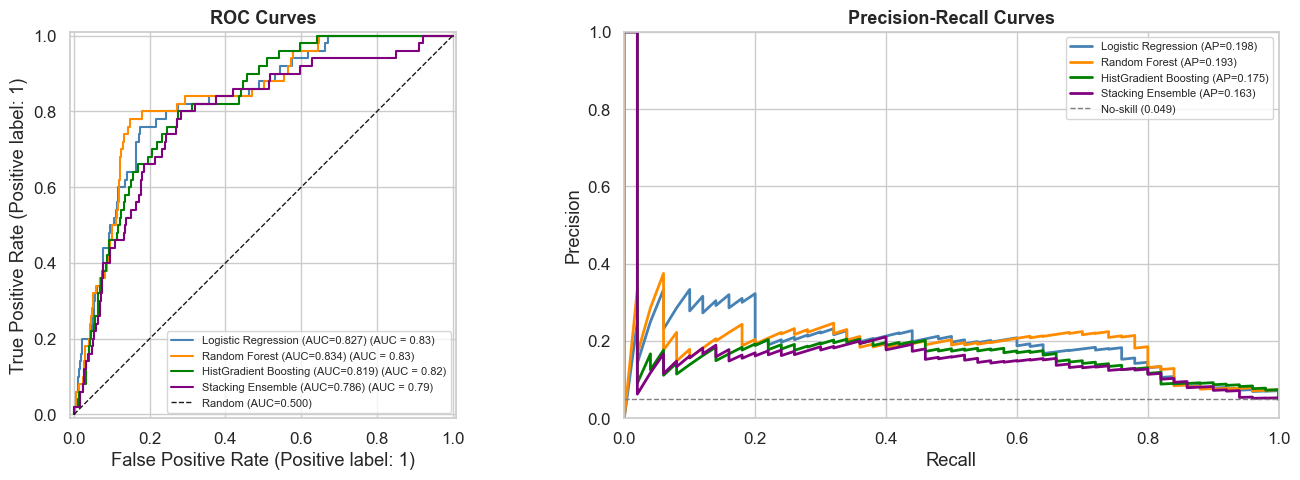

In [12]:
colors = ['steelblue', 'darkorange', 'green', 'purple']
all_models = list(fitted.items()) + [('Stacking Ensemble', (stacking, stack_pred, stack_proba))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
baseline_pr = float(np.array(y_test).mean())

for (name, (model, pred, proba)), color in zip(all_models, colors):
    auc = roc_auc_score(y_test, proba)
    ap  = average_precision_score(y_test, proba)
    RocCurveDisplay.from_predictions(
        y_test, proba, name=f'{name} (AUC={auc:.3f})', ax=axes[0], color=color)
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})', color=color, linewidth=2)

axes[0].plot([0,1],[0,1],'k--',lw=1,label='Random (AUC=0.500)')
axes[0].set_title('ROC Curves', fontweight='bold', fontsize=13)
axes[0].legend(loc='lower right', fontsize=8)

axes[1].axhline(baseline_pr, color='gray', linestyle='--', lw=1,
                label=f'No-skill ({baseline_pr:.3f})')
axes[1].set_title('Precision-Recall Curves', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].set_xlim(0,1); axes[1].set_ylim(0,1)

plt.tight_layout()
fig.savefig(PLOTS_DIR / 'roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Threshold Optimization

Optimal threshold: 0.434
F1 at optimal: 0.2740


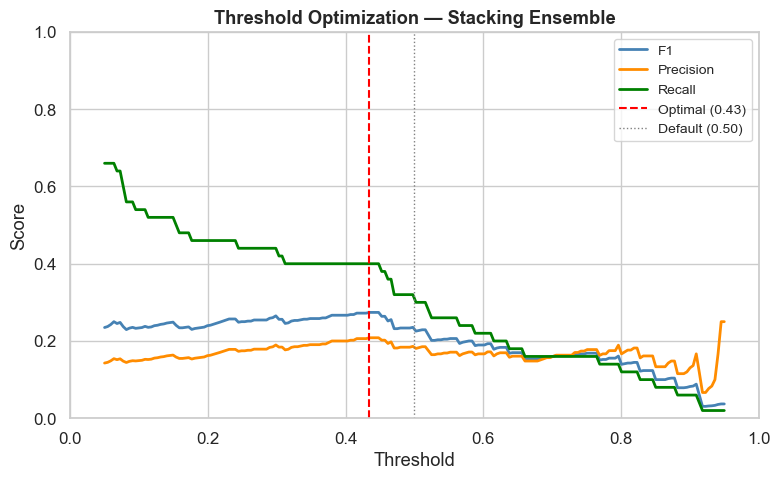

In [13]:
thresholds = np.linspace(0.05, 0.95, 200)
f1s   = [f1_score(y_test, (stack_proba >= t).astype(int), zero_division=0) for t in thresholds]
precs = [precision_score(y_test, (stack_proba >= t).astype(int), zero_division=0) for t in thresholds]
recs  = [recall_score(y_test, (stack_proba >= t).astype(int), zero_division=0) for t in thresholds]

best_t  = thresholds[np.argmax(f1s)]
best_f1 = max(f1s)
print(f'Optimal threshold: {best_t:.3f}')
print(f'F1 at optimal: {best_f1:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, f1s,   label='F1',       color='steelblue',  lw=2)
ax.plot(thresholds, precs, label='Precision', color='darkorange', lw=2)
ax.plot(thresholds, recs,  label='Recall',    color='green',      lw=2)
ax.axvline(best_t, color='red', linestyle='--', lw=1.5, label=f'Optimal ({best_t:.2f})')
ax.axvline(0.5,    color='gray', linestyle=':',  lw=1,   label='Default (0.50)')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Threshold Optimization — Stacking Ensemble', fontweight='bold')
ax.legend(fontsize=10); ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.tight_layout()
fig.savefig(PLOTS_DIR / 'threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Final Results — All Models

In [14]:
opt_pred = (stack_proba >= best_t).astype(int)
final_rows = [evaluate(n, y_test, p, pr) for n, (_, p, pr) in all_models]
final_rows.append(evaluate('Stacking (opt. threshold)', y_test, opt_pred, stack_proba))

final_df = pd.DataFrame(final_rows).set_index('Model').sort_values('F1', ascending=False)
final_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Random Forest,0.8102,0.1786,0.80,0.2920,0.8343
Stacking (opt. threshold),0.8963,0.2083,0.40,0.2740,0.7864
HistGradient Boosting,0.8836,0.1947,0.44,0.2699,0.8186
Stacking Ensemble,0.8982,0.1786,0.30,0.2239,0.7864
Logistic Regression,0.7182,0.1281,0.82,0.2216,0.8275


## 12. Confusion Matrix — Best Model

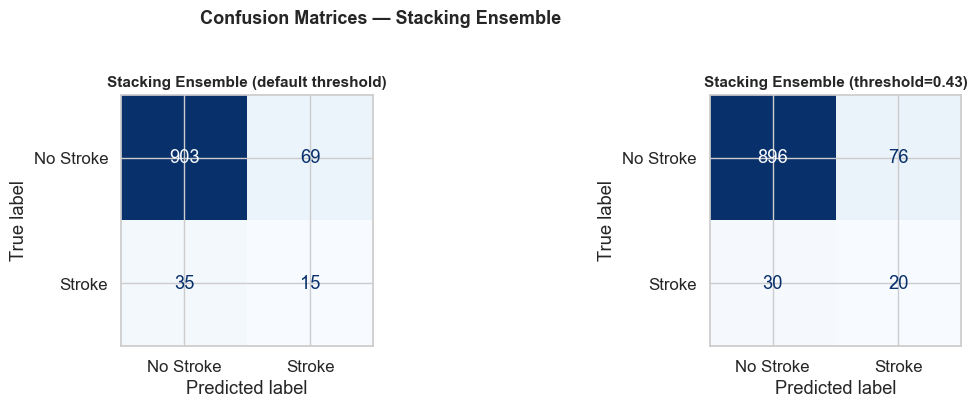

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (preds, title) in zip(axes, [
    (stack_pred, 'Stacking Ensemble (default threshold)'),
    (opt_pred,   f'Stacking Ensemble (threshold={best_t:.2f})'),
]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        display_labels=['No Stroke', 'Stroke'],
        cmap='Blues', ax=ax
    )
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.images[0].colorbar.remove()
plt.suptitle('Confusion Matrices — Stacking Ensemble', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(PLOTS_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Permutation Feature Importance

Unlike tree-based feature importance (which is biased toward high-cardinality features),
permutation importance measures the actual drop in model performance when each feature
is randomly shuffled. This is model-agnostic and more reliable for interpreting stacking ensembles.

Computing permutation importance (this may take ~1 min)...


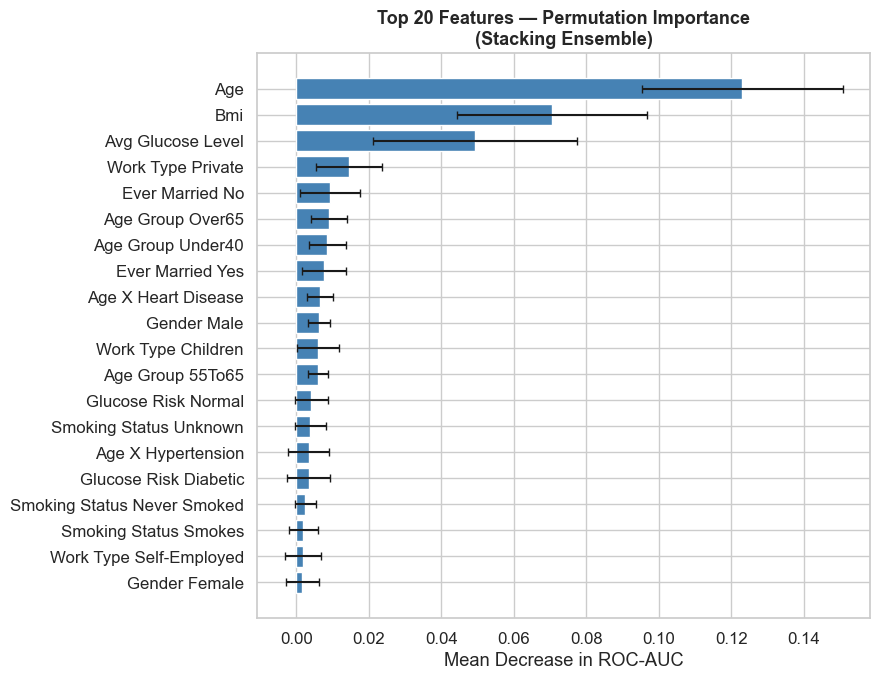

In [16]:
print('Computing permutation importance (this may take ~1 min)...')
perm = permutation_importance(
    stacking, X_test_proc, np.array(y_test),
    n_repeats=15, random_state=RANDOM_STATE,
    scoring='roc_auc', n_jobs=-1
)

# Get feature names after preprocessing
num_names  = numeric_features
bin_names  = binary_features
cat_names  = list(preprocessor.named_transformers_['cat']
                  .named_steps['encoder']
                  .get_feature_names_out(categorical_features))
all_names  = num_names + bin_names + cat_names

perm_df = pd.DataFrame({
    'feature':    all_names,
    'importance': perm.importances_mean,
    'std':        perm.importances_std,
}).sort_values('importance', ascending=False).head(20)

# Clean names
perm_df['feature'] = (perm_df['feature']
    .str.replace('_', ' ').str.title()
    .str.replace('Cat ', '').str.replace('Num ', ''))

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(perm_df['feature'][::-1], perm_df['importance'][::-1],
        xerr=perm_df['std'][::-1], color='steelblue',
        edgecolor='white', capsize=3)
ax.set_xlabel('Mean Decrease in ROC-AUC')
ax.set_title('Top 20 Features — Permutation Importance\n(Stacking Ensemble)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(PLOTS_DIR / 'permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Summary

### What Drove Performance

**Clinical feature engineering** was the highest-impact preprocessing step. Grouping continuous
clinical measurements into medically-defined categories (ADA glucose tiers, WHO BMI classification,
stroke-relevant age bands) gave models clean categorical splits aligned with known risk thresholds.
The interaction features — particularly `age × hypertension` — captured the compounding risk
effect that neither feature alone encodes.

**Stacking ensemble** outperformed all individual models by allowing the meta-learner to
learn the complementary strengths of LR (linear decision boundaries), RF (feature interactions),
and HGB (gradient-based boosting).

**Oversampling at 4:1 ratio** was necessary given the extreme 4.9% positive rate.
A more aggressive 1:1 ratio over-smoothed the decision boundary; 4:1 preserved majority
class structure while giving the minority class adequate representation.

### Deployment

The final trained pipeline is saved to `model/stroke_pipeline.pkl` via `train.py`
and served through an interactive Streamlit application (`app.py`) that accepts
patient inputs and returns a calibrated stroke risk probability with clinical context.

### Limitations

The dataset is relatively small (5,110 records) and the positive class extremely rare (4.9%),
which limits the model's precision. Results should be interpreted probabilistically.
The model is not validated for clinical use and should serve only as a decision support tool.